In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import CMR_IA as cmr
import json

cmr.analysis.setup_notebook()

SAVEFIG = False
SAVERES = False

## Load Data

In [2]:
# Load study, test data and semantic matrix
df_study = pd.read_parquet("data/simu2_study.parquet")
df_test = pd.read_parquet("data/simu2_test.parquet")
sem_mat = np.load("data/simu2_smat.npy")

In [3]:
# Inspect study data
df_study

,subject,list,itemno1,itemno2,study_pos,session
0,37,0,1154,-1,1,0
1,37,0,1121,-1,2,0
2,37,0,612,-1,3,0
3,37,0,907,-1,4,0
4,37,0,1358,-1,5,0
...,...,...,...,...,...,...
34939,172,5,1243,-1,60,90
34940,172,5,1077,-1,61,90
34941,172,5,1423,-1,62,90
34942,172,5,968,-1,63,90


In [4]:
# Inspect test data
df_test

,subject,list,recog_pos,itemno1,itemno2,old,old_lag,study_pos,study_lag,yes,session
0,37,0,1,195,-1,True,-999,9,56,1.0,0
1,37,0,2,493,-1,True,46,55,11,0.0,0
2,37,0,3,376,-1,True,-3,52,15,0.0,0
3,37,0,4,998,-1,True,-5,47,21,0.0,0
4,37,0,5,184,-1,False,-999,-99,-9999,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
69883,172,5,124,801,-1,False,-999,-99,-9999,0.0,90
69884,172,5,125,1335,-1,False,-999,-99,-9999,1.0,90
69885,172,5,126,1245,-1,True,-999,28,162,1.0,90
69886,172,5,127,747,-1,False,-999,-99,-9999,0.0,90


## Run CMR-IA

In [5]:
# Load fitted parameters
params = cmr.load_params("2", fixed_params={"c_thresh_itm": 1})
params

{'beta_enc': 0.258066,
 'beta_rec': None,
 'beta_cue': 0.28766,
 'beta_rec_post': 0.029796,
 'beta_distract': 0.406914,
 'beta_enc_inpair': None,
 's_fc': 0.758293,
 's_cf': 0.0,
 'phi_s': 0.0,
 'phi_d': 0.0,
 'psi_s': 0.0,
 'psi_c': 1.0,
 'd_assoc': None,
 'use_new_context': True,
 'use_flexible_thresh': True,
 'c_d': 5.171985,
 'thresh_kernel_len': 10,
 'c_thresh_itm': 1,
 'c_thresh_assoc': 1.0,
 'c_s': 0.0,
 'thresh_sigma': 0.0,
 'recog_slope': 1.0,
 'kappa': None,
 'eta': None,
 'omega': None,
 'alpha': None,
 'lamb': None,
 'c_thresh': None,
 'ban_recall': None,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 50,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'gamma_fc': 0.07213,
 'gamma_cf': 0.0}

In [6]:
# Run model or load saved results
if SAVERES:
    df_simu = cmr.run_norm_recog_multi_sess(params, df_study, df_test, sem_mat)
    df_simu = df_simu.merge(df_test, on=["session", "list", "itemno1", "itemno2"])
    df_simu.to_parquet("data/simu2_result.parquet")
else:
    df_simu = pd.read_parquet("data/simu2_result.parquet")
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes
0,0,0,195,-1,1,0,0.619815,0.604424,0.503848,37,1,True,-999,9,56,1.0
1,0,0,493,-1,1,0,0.665409,0.619728,0.511418,37,2,True,46,55,11,0.0
2,0,0,376,-1,0,0,0.640102,0.665150,0.493738,37,3,True,-3,52,15,0.0
3,0,0,998,-1,1,0,0.640570,0.640244,0.500082,37,4,True,-5,47,21,0.0
4,0,0,184,-1,0,0,0.639563,0.640568,0.499749,37,5,False,-999,-99,-9999,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69883,90,5,801,-1,0,0,0.636926,0.667910,0.492255,172,124,False,-999,-99,-9999,0.0
69884,90,5,1335,-1,1,0,0.645416,0.637102,0.502079,172,125,False,-999,-99,-9999,1.0
69885,90,5,1245,-1,1,0,0.665000,0.645368,0.504908,172,126,True,-999,28,162,1.0
69886,90,5,747,-1,0,0,0.659650,0.664888,0.498690,172,127,False,-999,-99,-9999,0.0


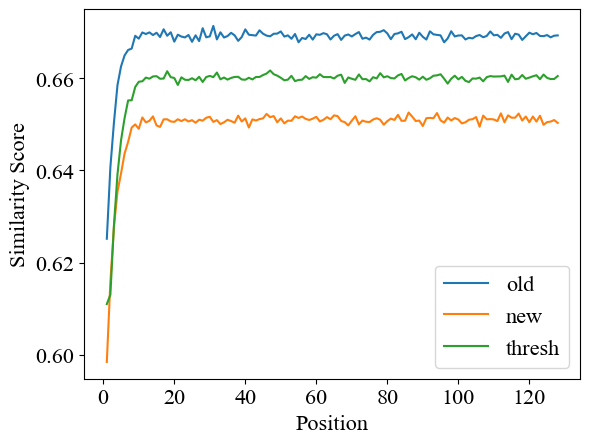

In [7]:
# Plot csim
old_csim = df_simu.query("old == True").groupby("recog_pos").csim.mean()
new_csim = df_simu.query("old == False").groupby("recog_pos").csim.mean()
thresh_mean = df_simu.groupby("recog_pos").thresh.mean()
pos = np.unique(df_simu.recog_pos)

plt.plot(np.unique(df_simu.query("old").recog_pos), old_csim, label="old")
plt.plot(np.unique(df_simu.query("~old").recog_pos), new_csim, label="new")
plt.plot(pos, thresh_mean, label="thresh")
plt.xlabel("Position")
plt.ylabel("Similarity Score")
plt.legend()
plt.show()

## Analysis

In [8]:
# Get conditions and propagate lag_cat to adjacent new items
def conditions(s):
    if s.old_lag == -999:
        return np.nan
    elif abs(s.old_lag) == 1:
        return "a"
    elif abs(s.old_lag) > 10:
        return "r"
    return np.nan


# Get lag category
df_simu["lag_cat"] = df_simu.apply(conditions, axis=1)

# Propagate lag_cat from an old item to the immediately following new item
recog_pos = df_simu.recog_pos.to_numpy()
old = df_simu.old.to_numpy()
lag_cat = df_simu.lag_cat.to_numpy()
lag_cat_with_new = [lag_cat[i - 1] if (recog_pos[i] > 1 and not old[i] and old[i - 1]) else lag_cat[i] for i in range(len(df_simu))]
df_simu["lag_cat"] = lag_cat_with_new

# new/old x lag_cat
create_level = {0: "new_r", 1: "new_a", 2: "old_r", 3: "old_a"}
df_t = df_simu.loc[pd.notna(df_simu.lag_cat)].copy()
df_t["level"] = df_t.apply(lambda x: create_level[x["old"] * 2 + (x["lag_cat"] == "a")], axis=1)
df_t

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes,lag_cat,level
1,0,0,493,-1,1,0,0.665409,0.619728,0.511418,37,2,True,46,55,11,0.0,r,old_r
10,0,0,996,-1,1,0,0.665883,0.655057,0.502706,37,11,True,-13,27,48,1.0,r,old_r
11,0,0,1398,-1,0,0,0.641848,0.665821,0.494007,37,12,False,-999,-99,-9999,0.0,r,new_r
17,0,0,285,-1,1,0,0.676571,0.647603,0.507241,37,18,True,-26,7,75,0.0,r,old_r
22,0,0,380,-1,0,0,0.668760,0.672302,0.499115,37,23,True,11,50,37,NaN,r,old_r
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69853,90,5,48,-1,1,0,0.687724,0.660075,0.506912,172,94,True,-16,20,138,0.0,r,old_r
69865,90,5,723,-1,0,0,0.658136,0.668973,0.497291,172,106,True,19,59,111,1.0,r,old_r
69866,90,5,724,-1,1,0,0.674831,0.658197,0.504158,172,107,True,-56,3,168,1.0,r,old_r
69882,90,5,1310,-1,0,0,0.667870,0.674814,0.498264,172,123,True,-23,38,149,1.0,r,old_r


In [9]:
# Check overall HR and FAR
far = df_simu.query("old == False").s_resp.mean()
df_overall = df_simu.query("old == True").groupby(["subject", "lag_cat"]).s_resp.mean().reset_index()
hr_a = df_overall.groupby("lag_cat").s_resp.mean()["a"]
hr_r = df_overall.groupby("lag_cat").s_resp.mean()["r"]
print(f"FAR={far:.3f}  HR_adjacent={hr_a:.3f}  HR_remote={hr_r:.3f}")

hr_a_gt, hr_r_gt, far_gt = 0.724046, 0.693084, 0.268861
err_simple = (abs(hr_a - hr_a_gt) + abs(hr_r - hr_r_gt)) / 2 + abs(far - far_gt)
print(f"Simple error: {err_simple:.4f}")

FAR=0.317  HR_adjacent=0.535  HR_remote=0.505
Simple error: 0.2363


### ROC

In [10]:
# Compute ROC curve
df_roc = cmr.analysis.compute_roc(df_t, thresh_arr=np.arange(0, 2, 0.001))
df_roc

level,new_a,new_r,old_a,old_r
0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0
...,...,...,...,...
1995,0.0,0.0,0.0,0.0
1996,0.0,0.0,0.0,0.0
1997,0.0,0.0,0.0,0.0
1998,0.0,0.0,0.0,0.0


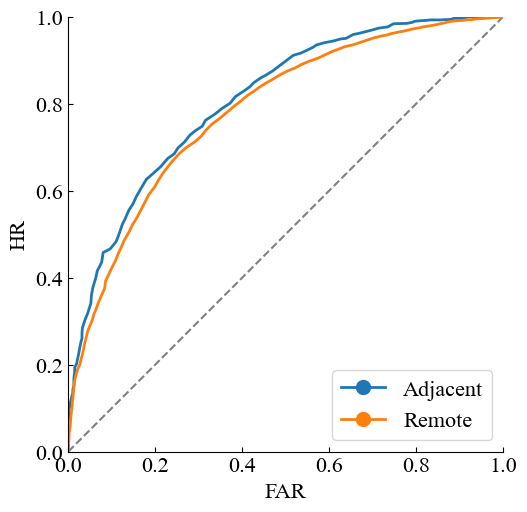

In [11]:
# Plot ROC curve
fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.1, top=0.97)
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="both", direction="in")
ax.plot([0, 1], [0, 1], color="grey", linestyle="dashed")
sns.lineplot(data=df_roc, x="new_a", y="old_a", ax=ax, estimator=None, linewidth=2)
sns.lineplot(data=df_roc, x="new_r", y="old_r", ax=ax, estimator=None, linewidth=2)
plt.ylim([0, 1])
plt.xlim([0, 1])
ticks = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.xticks(ticks=ticks)
plt.yticks(ticks=ticks)
plt.xlabel("FAR")
plt.ylabel("HR")
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, label="Adjacent"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, label="Remote"),
]
plt.legend(handles=legend_elements, loc="lower right")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu2_roc.pdf")
plt.show()

### ZROC

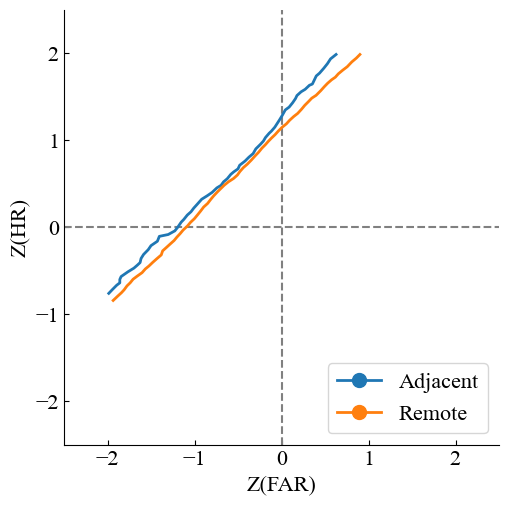

In [12]:
# Compute and plot zROC curve
df_zroc = cmr.analysis.compute_zroc(df_roc)
df_zroc_plot_a = df_zroc.query("-2 < z_new_a < 2 and -2 < z_old_a < 2")
df_zroc_plot_r = df_zroc.query("-2 < z_new_r < 2 and -2 < z_old_r < 2")

fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.1, top=0.97)
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="both", direction="in")
plt.axvline(x=0, color="grey", linestyle="dashed")
plt.axhline(y=0, color="grey", linestyle="dashed")
sns.lineplot(data=df_zroc_plot_a, x="z_new_a", y="z_old_a", ax=ax, estimator=None, linewidth=2)
sns.lineplot(data=df_zroc_plot_r, x="z_new_r", y="z_old_r", ax=ax, estimator=None, linewidth=2)
plt.xlim([-2.5, 2.5])
plt.ylim([-2.5, 2.5])
plt.xlabel("Z(FAR)")
plt.ylabel("Z(HR)")
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, label="Adjacent"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, label="Remote"),
]
plt.legend(handles=legend_elements, loc="lower right")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu2_zroc.pdf")
plt.show()

### Error Check

In [13]:
# Load ground truth and compute ROC error
with open("data/simu2_gt.json") as f:
    gt = json.load(f)
far_a_gt = np.array(gt["far_a"])
hr_a_gt = np.array(gt["hr_a"])
far_r_gt = np.array(gt["far_r"])
hr_r_gt = np.array(gt["hr_r"])

hr_a_interp = cmr.analysis.interpolate_roc(df_roc["new_a"].to_numpy(), df_roc["old_a"].to_numpy(), far_a_gt)
hr_r_interp = cmr.analysis.interpolate_roc(df_roc["new_r"].to_numpy(), df_roc["old_r"].to_numpy(), far_r_gt)
err = np.sum((hr_a_interp - hr_a_gt) ** 2) + np.sum((hr_r_interp - hr_r_gt) ** 2)
print(f"ROC error: {err}")
print(f"Adjacent ordering preserved: {np.all((hr_a_interp > hr_r_interp)[1:])}")

ROC error: 0.03440508841251977
Adjacent ordering preserved: True


### Alternative plots

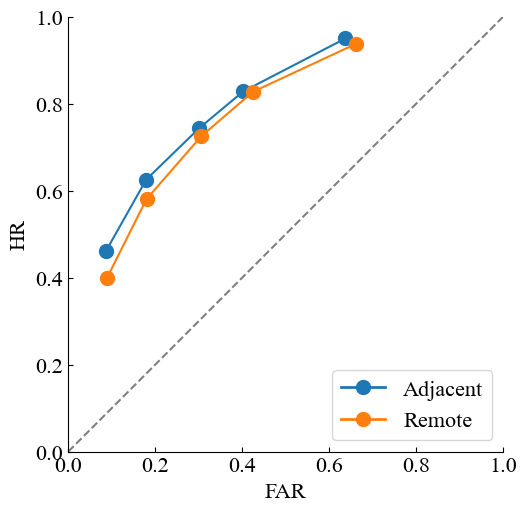

In [14]:
# Plot interpolated ROC at ground truth FAR points
fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.1, top=0.97)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
x = np.array([0, 1])
y = np.array([0, 1])
ax.plot(x, y, color="grey", linestyle="dashed")
plt.plot(far_a_gt, hr_a_interp, color=sns.color_palette()[0], marker="o", markersize=10, linestyle="-")
plt.plot(far_r_gt, hr_r_interp, color=sns.color_palette()[1], marker="o", markersize=10, linestyle="-")
plt.ylim([0, 1])
plt.xlim([0, 1])
ticks = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.xticks(ticks=ticks)
plt.yticks(ticks=ticks)
plt.xlabel("FAR")
plt.ylabel("HR")
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="-", label="Adjacent"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="-", label="Remote"),
]
plt.legend(handles=legend_elements, loc="lower right")
plt.show()